In [27]:
import sys

sys.path.append("..")

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import statistics as st
from datetime import datetime
import cartopy.crs as crs
import geopandas as gpd
import matplotlib.patches as mpatches
import cartopy.feature as cfeature
import matplotlib.image as mpimg
from src.data import nysm_data
import scipy.stats

In [29]:
nysm_df = nysm_data.load_nysm_data(gfs=False)

In [30]:
station = "VOOR"
metvar = "t2m"

In [31]:
nysm_df = nysm_df[nysm_df["station"] == station]
nysm_df

,station,valid_time,lat,lon,elev,tair,ta9m,td,relh,srad,pres,mslp,wspd_sonic_mean,wspd_sonic,wmax_sonic,wdir_sonic,snow_depth,precip_total
81841,VOOR,2018-01-01 01:00:00,42.65242,-73.975616,115.061996,-16.027559,-15.981810,-21.781937,61.206779,0.000000,1011.896973,1013.860840,4.561717,4.146896,7.660045,318.073090,0.112242,0.0
81842,VOOR,2018-01-01 02:00:00,42.65242,-73.975616,115.061996,-16.556549,-16.533449,-21.697220,64.441589,0.000000,1011.642029,1013.637268,6.401325,5.458067,10.785800,305.534088,0.111988,0.0
81843,VOOR,2018-01-01 03:00:00,42.65242,-73.975616,115.061996,-17.202271,-17.194059,-23.095764,60.145512,0.000000,1011.992981,1014.029358,6.375271,5.527372,9.397820,306.690094,0.113081,0.0
81844,VOOR,2018-01-01 04:00:00,42.65242,-73.975616,115.061996,-18.092300,-18.099079,-24.692047,56.228519,0.000007,1012.127991,1014.219910,5.485104,6.203581,10.109350,308.668701,0.111096,0.0
81845,VOOR,2018-01-01 05:00:00,42.65242,-73.975616,115.061996,-18.690821,-18.674601,-25.443848,55.282040,0.000027,1012.291992,1014.422058,4.585517,5.652416,8.552485,296.342285,0.111089,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060452,VOOR,2024-12-14 20:00:00,42.65242,-73.975616,115.061996,-1.192688,-1.482879,-11.441681,45.646309,189.096039,1031.904053,1033.080933,0.823686,1.064398,2.218586,33.196949,-0.001099,0.0
1060579,VOOR,2024-12-14 21:00:00,42.65242,-73.975616,115.061996,-3.297240,-3.058032,-9.996704,59.814060,17.437000,1032.124023,1033.419678,0.985886,0.786270,1.172874,268.968109,-0.001151,0.0
1060706,VOOR,2024-12-14 22:00:00,42.65242,-73.975616,115.061996,-5.607152,-4.462671,-9.495270,74.043571,0.036515,1032.270020,1033.697754,0.642201,1.102533,1.428661,246.273499,-0.001429,0.0
1060833,VOOR,2024-12-14 23:00:00,42.65242,-73.975616,115.061996,-6.882675,-5.729991,-9.800995,79.686127,0.017794,1032.687988,1034.191040,0.547037,0.658508,0.931038,231.001801,-0.003102,0.0


In [32]:
no_ls = ["station", "valid_time", "lat", "lon", "elev"]

In [33]:
for c in nysm_df.columns:
    if c not in no_ls:
        nysm_df[f"{c}_diff"] = nysm_df[c].diff()

In [34]:
for c in nysm_df.columns:
    if "diff" in c:
        nysm_df[f"{c}_diff_2"] = nysm_df[f"{c}"].diff()

In [35]:
nysm_df.dropna(inplace=True)
nysm_df.head()

,station,valid_time,lat,lon,elev,tair,ta9m,td,relh,srad,...,relh_diff_diff_2,srad_diff_diff_2,pres_diff_diff_2,mslp_diff_diff_2,wspd_sonic_mean_diff_diff_2,wspd_sonic_diff_diff_2,wmax_sonic_diff_diff_2,wdir_sonic_diff_diff_2,snow_depth_diff_diff_2,precip_total_diff_diff_2
81843,VOOR,2018-01-01 03:00:00,42.65242,-73.975616,115.061996,-17.202271,-17.194059,-23.095764,60.145512,0.000000,...,-7.530888,0.000000,0.605896,0.615662,-1.865661,-1.241866,-4.513734,13.695007,0.001347,0.0
81844,VOOR,2018-01-01 04:00:00,42.65242,-73.975616,115.061996,-18.092300,-18.099079,-24.692047,56.228519,0.000007,...,0.379086,0.000007,-0.215942,-0.201538,-0.864114,0.606904,2.099509,0.822601,-0.003078,0.0
81845,VOOR,2018-01-01 05:00:00,42.65242,-73.975616,115.061996,-18.690821,-18.674601,-25.443848,55.282040,0.000027,...,2.970512,0.000013,0.028992,0.011597,-0.009418,-1.227374,-2.268394,-14.305023,0.001977,0.0
81846,VOOR,2018-01-01 06:00:00,42.65242,-73.975616,115.061996,-19.067631,-18.936090,-25.566605,56.456242,0.000000,...,2.120682,-0.000047,0.289978,0.277527,-1.056090,-2.471287,-2.063029,66.083740,-0.000708,0.0
81847,VOOR,2018-01-01 07:00:00,42.65242,-73.975616,115.061996,-18.960991,-18.925871,-25.484329,56.362980,0.000000,...,-1.267464,0.000027,-0.419922,-0.452332,1.907170,4.371485,5.131645,-76.696838,0.001337,0.0


In [36]:
def calc_correlation(station, metvar, nysm_df):
    vals = []

    vt = nysm_df["valid_time"].tolist()

    for fh in np.arange(1, 19):
        # Load the forecast-hour-specific model output
        df = pd.read_parquet(
            f"/home/aevans/nwp_bias/src/machine_learning/data/nysm_hrrr/{station}/{station}_fh{fh}_{metvar}_HRRR_ml_output_linear.parquet"
        )

        df = df[df["valid_time"].isin(vt)]
        nysm_df_filtered = nysm_df[nysm_df["valid_time"].isin(df["valid_time"])]

        for c in nysm_df_filtered.columns:
            if "diff" in c:
                x_column = nysm_df_filtered[c].values
                y_column = df["diff"].values

                p_score_pers = scipy.stats.pearsonr(x_column, y_column)[1]
                if p_score_pers > 0.05:
                    pers = -999.99
                else:
                    pers = scipy.stats.pearsonr(x_column, y_column)[0]

                vals.append({"Column": c, "Correlation": pers, "fh": fh})

    correlation_df = pd.DataFrame(vals)
    correlation_df = correlation_df[correlation_df["Correlation"].abs() < 1.5]
    correlation_df = correlation_df.set_index(["fh", "Column"])

    return correlation_df

In [37]:
correlation_df = calc_correlation(station, metvar, nysm_df)

In [38]:
correlation_df.head()

Correlation
fh Column                
1  tair_diff    -0.105764
   ta9m_diff    -0.110852
   td_diff      -0.028777
   relh_diff     0.075957
   srad_diff    -0.012467

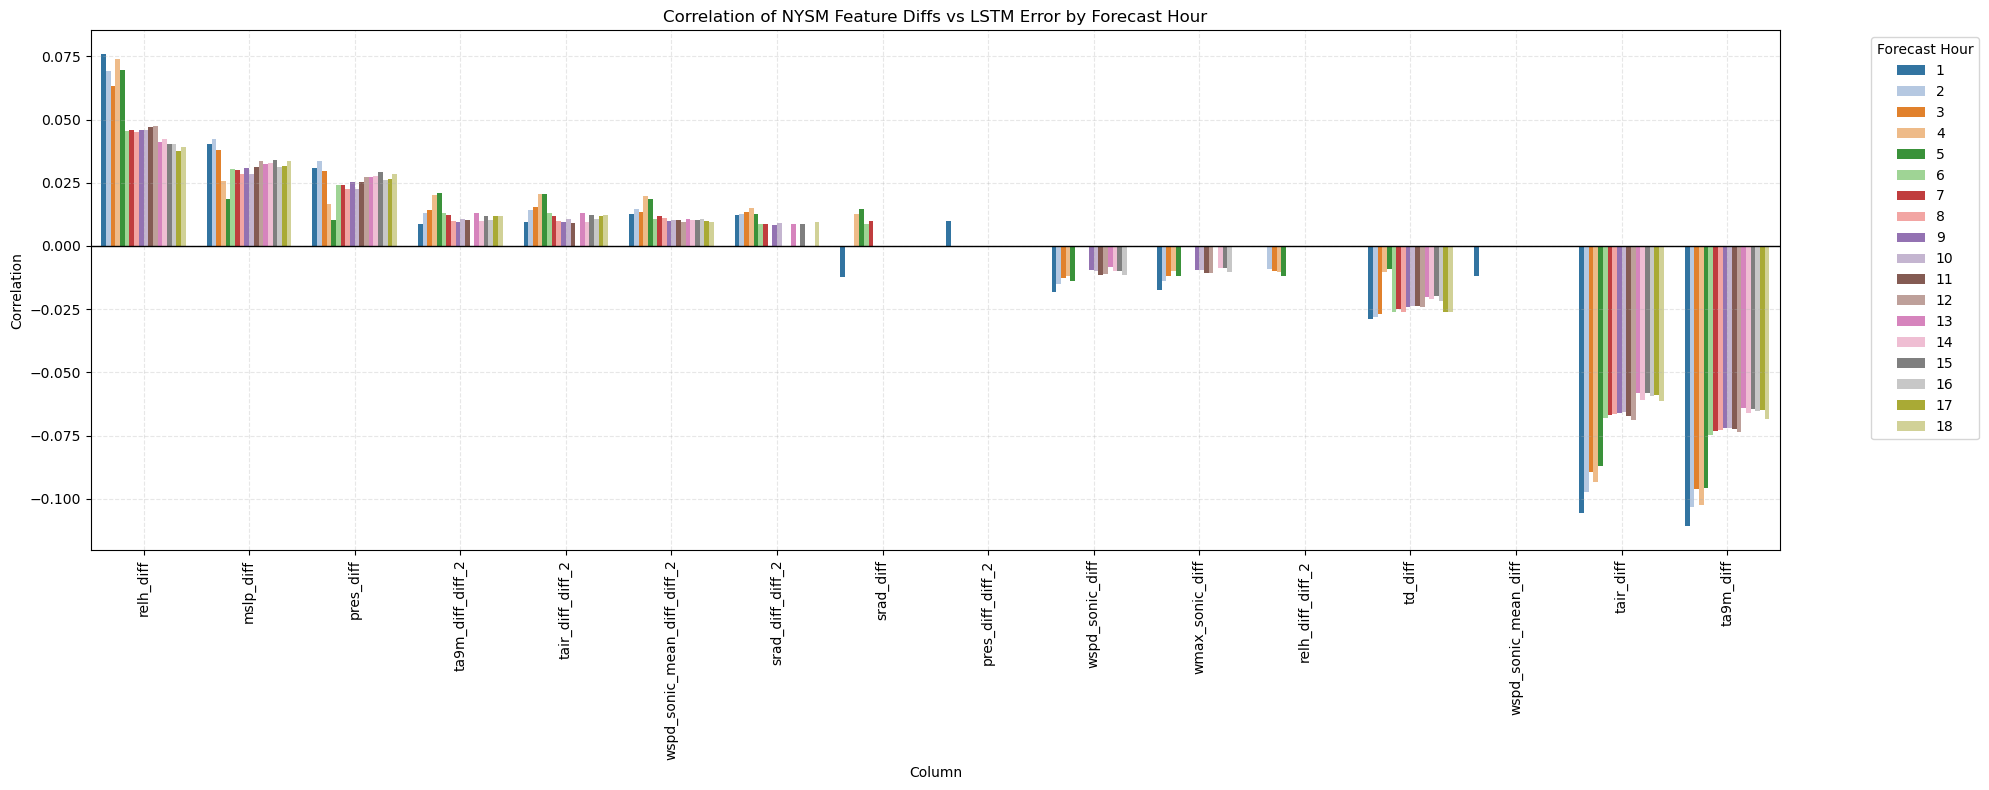

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to make 'fh' and 'Column' regular columns
df_plot = correlation_df.reset_index()
df_plot = df_plot.sort_values("Correlation", ascending=False)

plt.figure(figsize=(18, 8))
sns.barplot(data=df_plot, x="Column", y="Correlation", hue="fh", palette="tab20")

plt.axhline(0, color="black", linewidth=1)
plt.title("Correlation of NYSM Feature Diffs vs LSTM Error by Forecast Hour")
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend(title="Forecast Hour", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()